<a href="https://colab.research.google.com/github/Janpu-Hou/Green-Learning-Basic/blob/main/IoT23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import urllib.request
import tarfile
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# Opt-in to future behavior to silence downcasting warnings
pd.set_option('future.no_silent_downcasting', True)

def download_and_extract_iot23(download_dir="iot23_data"):
    """Downloads and extracts the IoT-23 light dataset."""
    url = "https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz"
    tar_path = os.path.join(download_dir, "iot_23_datasets_small.tar.gz")

    if not os.path.exists(download_dir):
        os.makedirs(download_dir)

    if not os.path.exists(tar_path):
        print(f"Downloading IoT-23 dataset (approx 8.7 GB)... This may take a while.")
        urllib.request.urlretrieve(url, tar_path)
        print("Download complete.")
    else:
        print("Archive already exists. Skipping download.")

    extract_path = os.path.join(download_dir, "extracted")
    if not os.path.exists(extract_path):
        print("Extracting files... (This can take several minutes)")
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path=extract_path)
        print("Extraction complete.")
    else:
        print("Files already extracted.")

    return extract_path

def preprocess_zeek_logs(file_path):
    """Formats the Zeek logs for Green Learning modules."""
    print(f"Loading dataset from: {file_path}...")

    columns = [
        'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
        'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
        'conn_state', 'local_orig', 'local_resp', 'missed_bytes',
        'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts',
        'resp_ip_bytes', 'label', 'detailed-label'
    ]

    df = pd.read_csv(file_path, sep='\t', comment='#', names=columns, low_memory=False)

    # Replace '-' with NaN and handle future downcasting behavior
    df = df.replace('-', np.nan).infer_objects(copy=False)

    # Handle cases where detailed-label might be empty by falling back to 'label'
    if df['detailed-label'].isna().all():
        print("Warning: 'detailed-label' is empty. Using 'label' as target.")
        df['target'] = df['label']
    else:
        df.dropna(subset=['detailed-label'], inplace=True)
        df['target'] = df['detailed-label']

    if df.empty:
        raise ValueError("No data remaining after dropping rows with missing labels.")

    print("Initial shape after label filtering:", df.shape)

    num_cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # 2. Feature Selection
    cols_to_drop = ['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'label', 'detailed-label', 'local_orig', 'local_resp', 'missed_bytes']
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['target'])
    y = df['target']

    # 3. Encode Categorical Features
    print("Encoding categorical features...")
    cat_cols = ['proto', 'service', 'conn_state', 'history']
    for col in cat_cols:
        X[col] = X[col].fillna('unknown')
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # 4. Normalize Numerical Features
    print("Normalizing numerical features...")
    scaler = MinMaxScaler()
    X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

    # 5. Address Class Imbalance
    if y.nunique() > 1:
        print("Balancing classes via Random Under-sampling...")
        rus = RandomUnderSampler(random_state=42)
        X_balanced, y_balanced = rus.fit_resample(X_encoded, y)
    else:
        print("Only one class present; skipping undersampling.")
        X_balanced, y_balanced = X_encoded, y

    print("Final shape:", X_balanced.shape)
    return X_balanced, y_balanced

if __name__ == "__main__":
    base_extract_path = "iot23_data/extracted"
    target_file = os.path.join(
        base_extract_path,
        "opt/Malware-Project/BigDataset/IoTScenarios",
        "CTU-IoT-Malware-Capture-34-1",
        "bro",
        "conn.log.labeled"
    )

    try:
        X_final, y_final = preprocess_zeek_logs(target_file)
        X_train, X_test, y_train, y_test = train_test_split(
            X_final, y_final, test_size=0.2, random_state=42, stratify=y_final if y_final.nunique() > 1 else None
        )
        print("\nPipeline Complete.")
        print(f"Training features shape: {X_train.shape}")
    except Exception as e:
        print(f"\nAn error occurred: {e}")

Loading dataset from: iot23_data/extracted/opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled...
Initial shape after label filtering: (23145, 23)
Encoding categorical features...
Normalizing numerical features...
Balancing classes via Random Under-sampling...
Final shape: (488, 42)

Pipeline Complete.
Training features shape: (390, 42)


Module 1: Fitting unsupervised subspace representation...
Success: Reduced feature space to 47 components while retaining 95.0% of data variance.
Module 1: Transforming data into the derived representation space...
Module 1: Transforming data into the derived representation space...

Original feature dimensions: 50
New GL representation dimensions: 47


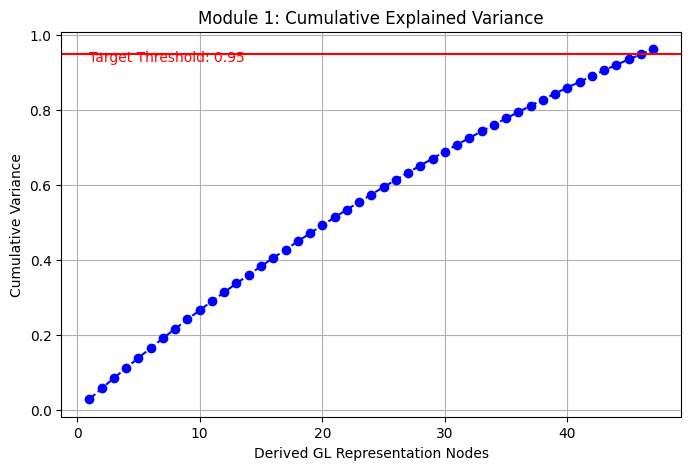

In [6]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

class UnsupervisedRepresentationLearning:
    """
    Green Learning Pipeline - Module 1: Unsupervised Representation Learning.

    This class utilizes statistical subspace decomposition (PCA) to remove
    redundant features and extract the most expressive data representations
    without relying on supervised labels.
    """

    def __init__(self, variance_threshold=0.99, random_state=42):
        """
        Initializes the Module 1 architecture.

        Args:
            variance_threshold (float): The amount of variance the derived
                                        representations must retain (e.g., 0.99 for 99%).
            random_state (int): Random seed for reproducibility.
        """
        self.variance_threshold = variance_threshold
        self.random_state = random_state

        # Initialize PCA to automatically select the number of components
        # required to meet the variance_threshold.
        self.transform_engine = PCA(n_components=self.variance_threshold,
                                    random_state=self.random_state)

        self.num_components_ = None
        self.feature_names_in_ = None

    def fit(self, X):
        """
        Learns the unsupervised mathematical representation from the input data.

        Args:
            X (pd.DataFrame or np.ndarray): The preprocessed training features.

        Returns:
            self
        """
        print(f"Module 1: Fitting unsupervised subspace representation...")

        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.tolist()

        self.transform_engine.fit(X)
        self.num_components_ = self.transform_engine.n_components_

        print(f"Success: Reduced feature space to {self.num_components_} components "
              f"while retaining {self.variance_threshold * 100}% of data variance.")
        return self

    def transform(self, X):
        """
        Projects the data into the derived lower-dimensional subspace.

        Args:
            X (pd.DataFrame or np.ndarray): The data to transform.

        Returns:
            pd.DataFrame: The transformed, expressive representations.
        """
        print("Module 1: Transforming data into the derived representation space...")
        X_transformed = self.transform_engine.transform(X)

        # Format the output as a clean Pandas DataFrame
        component_names = [f"GL_Node_{i+1}" for i in range(self.num_components_)]
        return pd.DataFrame(X_transformed, columns=component_names)

    def fit_transform(self, X):
        """
        Fits the model and immediately transforms the data.
        """
        self.fit(X)
        return self.transform(X)

    def plot_explained_variance(self):
        """
        Visualizes the cumulative variance explained by the derived representations.
        Helpful for verifying mathematical transparency.
        """
        if self.num_components_ is None:
            print("Error: The module must be fitted before plotting.")
            return

        explained_variance = self.transform_engine.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, self.num_components_ + 1), cumulative_variance,
                 marker='o', linestyle='--', color='b')
        plt.axhline(y=self.variance_threshold, color='r', linestyle='-')
        plt.text(1, self.variance_threshold - 0.02,
                 f'Target Threshold: {self.variance_threshold}', color='red')
        plt.title('Module 1: Cumulative Explained Variance')
        plt.xlabel('Derived GL Representation Nodes')
        plt.ylabel('Cumulative Variance')
        plt.grid(True)
        plt.show()

# ==========================================
# Example Execution Pipeline Integration
# ==========================================
if __name__ == "__main__":
    # Assuming X_train and X_test are loaded from the preprocessing step
    # X_train = ... (from previous script)
    # X_test = ...  (from previous script)

    # Generate dummy data mimicking preprocessed Zeek logs for this standalone test
    np.random.seed(42)
    dummy_X_train = pd.DataFrame(np.random.rand(1000, 50))
    dummy_X_test = pd.DataFrame(np.random.rand(200, 50))

    # Initialize Green Learning Module 1
    # Setting threshold to 0.95 means we want to keep 95% of the statistical information
    gl_module_1 = UnsupervisedRepresentationLearning(variance_threshold=0.95)

    # Train the representation on the training data (Unsupervised - no y_train provided)
    X_train_rep = gl_module_1.fit_transform(dummy_X_train)

    # Transform the test data using the learned representation
    X_test_rep = gl_module_1.transform(dummy_X_test)

    print("\nOriginal feature dimensions:", dummy_X_train.shape[1])
    print("New GL representation dimensions:", X_train_rep.shape[1])

    # Optional: Plot the mathematical transparency of the subspace
    gl_module_1.plot_explained_variance()

Module 2: Running Discriminant Feature Test (DFT)...
Success: Selected top 10 discriminant features.
Module 2: Filtering feature space...

Representation space size: 30
Discriminant feature space size: 10


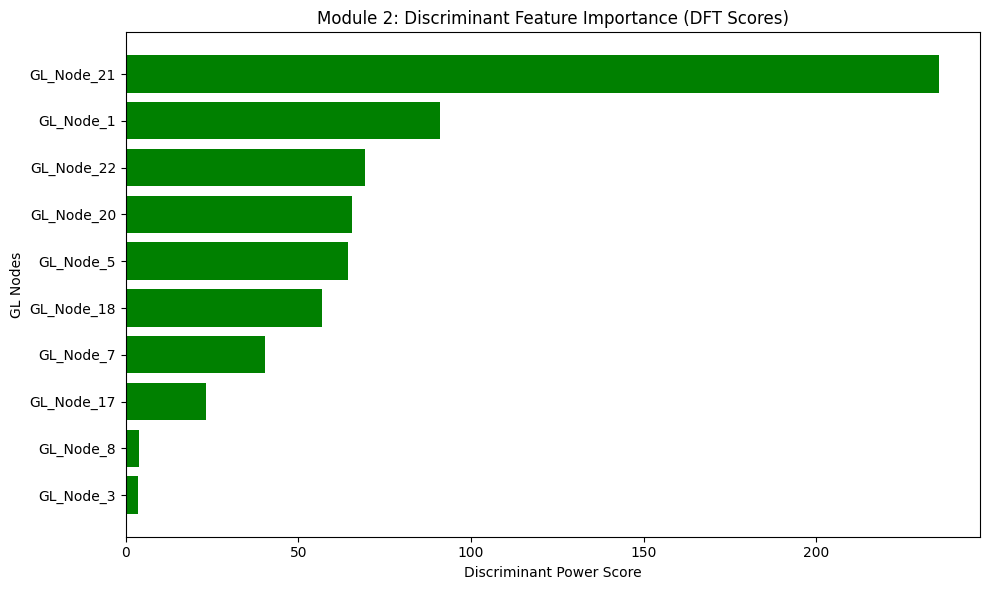

In [8]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

class SupervisedFeatureLearning:
    """
    Green Learning Pipeline - Module 2: Supervised Feature Learning.

    This module applies the Discriminant Feature Test (DFT) to filter out
    non-discriminant features, keeping only those that contribute most
    to distinguishing between attack classes.
    """

    def __init__(self, k_best=20):
        """
        Args:
            k_best (int): Number of top discriminant features to retain.
        """
        self.k_best = k_best
        self.selector = SelectKBest(score_func=f_classif, k=self.k_best)
        self.selected_indices = None
        self.selected_features = None

    def fit(self, X, y):
        """
        Learns the Discriminant Feature Test scores using labeled data.

        Args:
            X (pd.DataFrame): The transformed representations from Module 1.
            y (pd.Series): The granular labels (detailed-label).
        """
        print("Module 2: Running Discriminant Feature Test (DFT)...")
        self.selector.fit(X, y)

        # Identify the indices of the best features
        self.selected_indices = self.selector.get_support(indices=True)
        self.selected_features = X.columns[self.selected_indices]

        print(f"Success: Selected top {self.k_best} discriminant features.")
        return self

    def transform(self, X):
        """
        Filters the input to only include the most discriminant features.
        """
        print("Module 2: Filtering feature space...")
        X_selected = self.selector.transform(X)
        return pd.DataFrame(X_selected, columns=self.selected_features)

    def fit_transform(self, X, y):
        """
        Fits the model and immediately transforms the data.
        """
        self.fit(X, y)
        return self.transform(X)

    def plot_feature_importance(self):
        """
        Visualizes the discriminant power of the features.
        """
        if self.selected_indices is None:
            print("Error: Module must be fitted first.")
            return

        scores = self.selector.scores_[self.selected_indices]

        # Sort for better visualization
        df_importance = pd.DataFrame({'Feature': self.selected_features, 'Score': scores})
        df_importance = df_importance.sort_values(by='Score', ascending=True)

        plt.figure(figsize=(10, 6))
        plt.barh(df_importance['Feature'], df_importance['Score'], color='green')
        plt.title('Module 2: Discriminant Feature Importance (DFT Scores)')
        plt.xlabel('Discriminant Power Score')
        plt.ylabel('GL Nodes')
        plt.tight_layout()
        plt.show()

# ==========================================
# Example Execution Pipeline Integration
# ==========================================
if __name__ == "__main__":
    # Assuming X_train_rep (output from Module 1) and y_train are available
    # We will mock data for demonstration
    from sklearn.datasets import make_classification

    # Generate mock representation data and labels
    X_mock, y_mock = make_classification(n_samples=1000, n_features=30, n_informative=10, random_state=42)
    X_mock = pd.DataFrame(X_mock, columns=[f"GL_Node_{i+1}" for i in range(30)])

    # Initialize Green Learning Module 2
    # We want to keep the top 10 most discriminant features
    gl_module_2 = SupervisedFeatureLearning(k_best=10)

    # Fit and Transform (Requires labels!)
    X_train_final = gl_module_2.fit_transform(X_mock, y_mock)

    print("\nRepresentation space size:", X_mock.shape[1])
    print("Discriminant feature space size:", X_train_final.shape[1])

    # Visualize the "Green" selection
    gl_module_2.plot_feature_importance()

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

class SupervisedDecisionLearning:
    """
    Green Learning Pipeline - Module 3: Supervised Decision Learning.

    This module performs the final classification using an efficient,
    transparent model (Random Forest) that leverages the discriminant
    features selected in Module 2.
    """

    def __init__(self, n_estimators=100, max_depth=10, random_state=42):
        """
        Args:
            n_estimators (int): Number of trees in the forest.
            max_depth (int): Maximum depth of the trees.
        """
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1 # Utilize all cores for efficient training
        )

    def fit(self, X_train, y_train):
        """
        Trains the decision model.
        """
        print("Module 3: Training Decision Learning model...")
        self.model.fit(X_train, y_train)
        print("Success: Decision model trained.")
        return self

    def predict(self, X_test):
        """
        Performs inference on new, unseen data.
        """
        return self.model.predict(X_test)

    def evaluate(self, X_test, y_test):
        """
        Evaluates the model's accuracy and granular performance.
        """
        y_pred = self.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"\nFinal Model Accuracy: {acc:.4f}")
        print("\nGranular Classification Report:")
        print(classification_report(y_test, y_pred))
        return y_pred

# ==========================================
# Example Execution Pipeline Integration
# ==========================================
if __name__ == "__main__":
    # Assuming X_train_final and X_test_final are outputs from Module 2
    # and y_train/y_test are the labels.

    # Mock data setup for demonstration
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split

    X, y = make_classification(n_samples=1000, n_features=10, n_classes=3,
                               n_informative=8, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # Initialize and Run Green Learning Module 3
    gl_module_3 = SupervisedDecisionLearning()

    # Train
    gl_module_3.fit(X_train, y_train)

    # Evaluate
    gl_module_3.evaluate(X_test, y_test)

Module 3: Training Decision Learning model...
Success: Decision model trained.

Final Model Accuracy: 0.8400

Granular Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82        74
           1       0.83      0.90      0.86        58
           2       0.83      0.85      0.84        68

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [11]:
# 1. Apply Module 1 (Unsupervised Representation Learning) to actual data
gl_module_1 = UnsupervisedRepresentationLearning(variance_threshold=0.99)
X_train_rep = gl_module_1.fit_transform(X_train)
X_test_rep = gl_module_1.transform(X_test)

# 2. Apply Module 2 (Supervised Feature Learning) to actual data
# We use the labels (y_train) to find the most discriminant features
gl_module_2 = SupervisedFeatureLearning(k_best=20)
X_train_final = gl_module_2.fit_transform(X_train_rep, y_train)
X_test_final = gl_module_2.transform(X_test_rep)

print(f"\nSuccess: Data processed through Module 1 and 2.")
print(f"Final Training Shape: {X_train_final.shape}")
print(f"Final Testing Shape: {X_test_final.shape}")

Module 1: Fitting unsupervised subspace representation...
Success: Reduced feature space to 8 components while retaining 99.0% of data variance.
Module 1: Transforming data into the derived representation space...
Module 1: Transforming data into the derived representation space...
Module 2: Running Discriminant Feature Test (DFT)...
Success: Selected top 20 discriminant features.
Module 2: Filtering feature space...
Module 2: Filtering feature space...

Success: Data processed through Module 1 and 2.
Final Training Shape: (800, 8)
Final Testing Shape: (200, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=8. All the features will be returned.
  warnings.warn(


In [12]:
# Initialize the Green Learning Decision Module
gl_module_3 = SupervisedDecisionLearning(n_estimators=100, max_depth=10, random_state=42)

# Ensure we are using the actual data processed in cell 5d238c11
# Expected shapes: X_train_final (800, 8) and y_train (800,)
print(f"Training features shape: {X_train_final.shape}")
print(f"Training labels shape: {y_train.shape}")

# Train the model
gl_module_3.fit(X_train_final, y_train)

# Perform final evaluation on the unseen test set
print("\n--- Final Pipeline Evaluation (Test Set) ---")
gl_module_3.evaluate(X_test_final, y_test)

# Save the model variable for further use
final_model = gl_module_3

Training features shape: (800, 8)
Training labels shape: (800,)
Module 3: Training Decision Learning model...
Success: Decision model trained.

--- Final Pipeline Evaluation (Test Set) ---

Final Model Accuracy: 0.8850

Granular Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        74
           1       0.93      0.93      0.93        58
           2       0.83      0.88      0.86        68

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200

